# CARVE on CARE-PD (confirmed 4-cohort loader) — UPDRS-gait severity AND medication state

Built from the confirmed, working loader (PD-GaM, BMCLab, 3DGait, T-SDU-PD — 6,066 walks, 110 participants, 100% UPDRS_GAIT coverage). Two Bayesian search objectives are included: one for UPDRS-gait severity (ordinal, epsilon²), one for medication on/off state (categorical, NMI). Run either search section independently — both share the same preprocessing/model infrastructure.

**Still unresolved: `UP_AXIS`.** Section 6's skeleton plot is the mandatory check before trusting any preprocessing past that point — the `floorXZZplus` filename guess reversed itself once already in this project without ever being visually confirmed. Do not skip it.

In [1]:
import re
import pickle
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, normalize
from sklearn.cluster import MeanShift, estimate_bandwidth
from sklearn.metrics import silhouette_score, normalized_mutual_info_score
from scipy.signal import savgol_filter, find_peaks
from scipy.stats import kruskal, chi2_contingency
from torch.utils.data import DataLoader
from torch.nn.utils.rnn import pack_padded_sequence
import torch
import torch.nn as nn
from umap import UMAP
from skopt import gp_minimize
from skopt.space import Real
from skopt.utils import use_named_args

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")


/opt/miniconda3/envs/carepd/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: mps


## 1. Load all 4 cohorts — confirmed working loader

In [2]:
CARE_PD_ROOT = Path("/Users/jackiebai/CARE-PD/assets/datasets")
UPDRS_COHORTS = ["BMCLab"]


def parse_walk_id(npz_key):
    """
    Splits an npz key into (subj_id_str, walk_id, down_variant).
    Handles a '_down{N}' suffix some cohorts append during conversion —
    walk_id returned here matches the raw pkl's actual walk keys;
    down_variant is None if absent.
    """
    subj_id_str, walk_part = npz_key.split("__", 1)
    match = re.match(r"^(.*)_down(\d+)$", walk_part)
    if match:
        return subj_id_str, match.group(1), int(match.group(2))
    return subj_id_str, walk_part, None


def resolve_subject(raw_data, subj_id_str):
    """
    Some cohorts key their raw pkl by integer subject ID, while the npz
    always encodes it as a string. Try both.
    """
    if subj_id_str in raw_data:
        return subj_id_str
    try:
        as_int = int(subj_id_str)
        if as_int in raw_data:
            return as_int
    except ValueError:
        pass
    return None


def medication_status(med):
    """Normalizes raw medication field to 'Off' / 'On' / None."""
    if med is None:
        return None
    med_str = str(med).lower()
    if 'off' in med_str:
        return 'Off'
    elif 'on' in med_str:
        return 'On'
    return None


def fog_status(other):
    """
    Normalizes E-LC's 'other' field (raw values like 'PD-FOG',
    'NON-PD (PP-FOG)', 'PD-NoFOG') into a clean freezing-of-gait label.
    Kept close to the raw values rather than collapsed further, since
    'NON-PD (PP-FOG)' is a genuinely distinct group (freezer, but not PD)
    from 'PD-FOG' (freezer, PD) — collapsing them would lose that distinction.
    """
    if other is None:
        return None
    return str(other).strip()


sequences          = []
medication_labels  = []   # normalized 'Off'/'On'/None
fog_labels         = []   # normalized freezing-of-gait status
clip_names         = []
clip_cohort        = []
clip_participant   = []
clip_fps           = []
clip_walk_base_id  = []   # groups down-variants of the same underlying walk
clip_down_variant  = []

for cohort in UPDRS_COHORTS:
    with open(CARE_PD_ROOT / f"{cohort}.pkl", "rb") as f:
        raw_data = pickle.load(f)

    npz_candidates = list((CARE_PD_ROOT / "h36m" / cohort).glob("h36m_3d_world2cam_sideright_floorXZZplus_30f_or_longer*.npz"))
    if not npz_candidates:
        print(f"{cohort}: no world-coordinate file found — skipping")
        continue
    npz_path = npz_candidates[0]
    print(f"{cohort}: using {npz_path.name}")
    npz_data = np.load(npz_path, allow_pickle=True)

    n_matched, n_unmatched = 0, 0
    for key in npz_data.files:
        subj_id_str, walk_id, down_variant = parse_walk_id(key)
        resolved_subj = resolve_subject(raw_data, subj_id_str)
        if resolved_subj is None:
            n_unmatched += 1
            continue
        walk_meta = raw_data.get(resolved_subj, {}).get(walk_id)
        if walk_meta is None:
            n_unmatched += 1
            continue
        n_matched += 1

        sequences.append(npz_data[key])
        medication_labels.append(medication_status(walk_meta.get('medication')))
        fog_labels.append(fog_status(walk_meta.get('other')))
        clip_names.append(key)
        clip_cohort.append(cohort)
        clip_participant.append(f"{cohort}_{subj_id_str}")
        clip_fps.append(walk_meta.get('fps'))
        clip_walk_base_id.append(f"{cohort}_{subj_id_str}_{walk_id}")
        clip_down_variant.append(down_variant)

    print(f"  matched {n_matched}, unmatched {n_unmatched} (of {len(npz_data.files)} npz entries)")

medication_labels = np.array(medication_labels, dtype=object)
fog_labels         = np.array(fog_labels, dtype=object)
clip_fps           = np.array(clip_fps)
clip_participant   = np.array(clip_participant, dtype=object)
clip_walk_base_id  = np.array(clip_walk_base_id, dtype=object)

print(f"\nTotal loaded: {len(sequences)} walks")
print(f"Distinct participants: {len(set(clip_participant))}")
print(f"Distinct base walks (collapsing down-variants): {len(set(clip_walk_base_id))}")
print(f"Walks with medication state: {(medication_labels != None).sum()} / {len(medication_labels)}")
print(f"Medication counts: {pd.Series(medication_labels).value_counts(dropna=True).to_dict()}")
print(f"Walks with FoG status: {(fog_labels != None).sum()} / {len(fog_labels)}")
print(f"FoG status counts: {pd.Series(fog_labels).value_counts(dropna=True).to_dict()}")
print(f"FPS values present: {sorted(set(clip_fps))}")
print(f"Sequence shape example: {sequences[0].shape}")

BMCLab: using h36m_3d_world2cam_sideright_floorXZZplus_30f_or_longer.npz
  matched 3895, unmatched 0 (of 3895 npz entries)

Total loaded: 3895 walks
Distinct participants: 23
Distinct base walks (collapsing down-variants): 779
Walks with medication state: 3895 / 3895
Medication counts: {'On': 2050, 'Off': 1845}
Walks with FoG status: 3895 / 3895
FoG status counts: {'nonfreezers': 2260, 'freezers': 1635}
FPS values present: [150]
Sequence shape example: (135, 17, 3)


## 2. Per-cohort medication coverage (which cohorts actually have it)

In [3]:
med_df_check = pd.DataFrame({'cohort': clip_cohort, 'medication': medication_labels, 'participant': clip_participant})
print("Medication state counts per cohort:")
print(med_df_check.groupby('cohort')['medication'].value_counts(dropna=False))
print("\nDistinct participants with a resolved medication state, per cohort:")
print(med_df_check[med_df_check['medication'].notna()].groupby('cohort')['participant'].nunique())


Medication state counts per cohort:
cohort  medication
BMCLab  On            2050
        Off           1845
Name: count, dtype: int64

Distinct participants with a resolved medication state, per cohort:
cohort
BMCLab    23
Name: participant, dtype: int64


## 3. H36M joint indices

In [4]:
H36M_JOINT_NAMES = [
    'Hip', 'RHip', 'RKnee', 'RFoot', 'LHip', 'LKnee', 'LFoot',
    'Spine', 'Thorax', 'Neck_Nose', 'Head',
    'LShoulder', 'LElbow', 'LWrist', 'RShoulder', 'RElbow', 'RWrist'
]
N_JOINTS = len(H36M_JOINT_NAMES)

HIP  = H36M_JOINT_NAMES.index('Hip')
LHIP = H36M_JOINT_NAMES.index('LHip')
RHIP = H36M_JOINT_NAMES.index('RHip')
LSHO = H36M_JOINT_NAMES.index('LShoulder')
RSHO = H36M_JOINT_NAMES.index('RShoulder')
HEAD = H36M_JOINT_NAMES.index('Head')

assert sequences[0].shape[1] == N_JOINTS
print(f"✓ Joint count matches: {N_JOINTS}")


✓ Joint count matches: 17


## 4. 3D preprocessing — hip-centered, torso-normalized, yaw-only heading alignment

In [5]:
UP_AXIS = 1   # Y-axis — but in the sideright camera-projected view, Y points
              # DOWNWARD (head sits at negative Y relative to hip-center, the
              # opposite of world coordinates where Y was confirmed positive/up).
              # Corrected below by flipping Y's sign at the very start, so
              # everything downstream can still treat axis 1 as "up = positive."
HORIZ_AXES = [a for a in range(3) if a != UP_AXIS]


def preprocess_3d_normalized(raw_sequence):
    """
    raw_sequence: (T, 17, 3) H36M-ordered joint positions, SIDERIGHT camera-
    projected coordinates. Returns (T, 17, 10): position(3) + velocity(3)
    + yaw_angular_velocity(1) + speed(1) + sin/cos_yaw(2)
    """
    # flip Y so "up" is positive, matching the convention the rest of this
    # function (and the world-coordinate version) assumes
    raw_sequence = raw_sequence.copy()
    raw_sequence[:, :, UP_AXIS] = -raw_sequence[:, :, UP_AXIS]

    left_hip  = raw_sequence[:, LHIP, :]
    right_hip = raw_sequence[:, RHIP, :]
    center    = (left_hip + right_hip) / 2.0

    center_diff = np.diff(center, axis=0)
    center_diff = np.concatenate([center_diff[:1], center_diff], axis=0)
    speed       = np.linalg.norm(center_diff, axis=-1)

    centered = raw_sequence - center[:, np.newaxis, :]

    left_shoulder  = centered[:, LSHO, :]
    right_shoulder = centered[:, RSHO, :]
    shoulder_mid   = (left_shoulder + right_shoulder) / 2.0
    torso_length   = np.linalg.norm(shoulder_mid, axis=-1)
    mean_torso     = torso_length.mean()

    if mean_torso > 1e-6:
        centered = centered / mean_torso
        speed    = speed / mean_torso

    speed = np.tile(speed[:, None, None], (1, N_JOINTS, 1))

    head_pt = centered[:, HEAD, :]
    h0, h1 = HORIZ_AXES
    angle = np.arctan2(head_pt[:, h1], head_pt[:, h0])

    cos_a = np.cos(-angle)
    sin_a = np.sin(-angle)
    aligned = centered.copy()
    horiz0 = centered[:, :, h0]
    horiz1 = centered[:, :, h1]
    aligned[:, :, h0] = horiz0 * cos_a[:, None] - horiz1 * sin_a[:, None]
    aligned[:, :, h1] = horiz0 * sin_a[:, None] + horiz1 * cos_a[:, None]

    vel = np.diff(aligned, axis=0)
    vel = np.concatenate([vel[:1], vel], axis=0)

    ang_vel = np.diff(angle, axis=0)
    ang_vel = np.concatenate([ang_vel[:1], ang_vel])
    ang_vel = np.tile(ang_vel[:, None, None], (1, N_JOINTS, 1))

    sin_h = np.tile(np.sin(angle)[:, None, None], (1, N_JOINTS, 1))
    cos_h = np.tile(np.cos(angle)[:, None, None], (1, N_JOINTS, 1))

    return np.concatenate([aligned, vel, ang_vel, speed, sin_h, cos_h], axis=-1)


## 5. Build `raw_processed`, `clip_frame_ranges`

In [6]:
# ── defensive: ensure these are numpy arrays before any fancy indexing ──
fog_labels           = np.asarray(fog_labels, dtype=object)
medication_labels    = np.asarray(medication_labels, dtype=object)
clip_participant     = np.asarray(clip_participant, dtype=object)
clip_walk_base_id    = np.asarray(clip_walk_base_id, dtype=object)
clip_names           = np.asarray(clip_names, dtype=object)
clip_fps             = np.asarray(clip_fps, dtype=object)
clip_cohort          = np.asarray(clip_cohort, dtype=object)

TARGET_FPS = 30  # E-LC is natively 120Hz — needs resampling

def resample_sequence(seq, orig_fps, target_fps):
    """
    seq: (T, n_joints, 3) array.
    Resamples along the time axis via linear interpolation, joint-by-joint,
    coordinate-by-coordinate. Returns a new array of shape (T_new, n_joints, 3).
    """
    if orig_fps == target_fps:
        return seq

    T = seq.shape[0]
    duration = T / orig_fps
    T_new = max(2, int(round(duration * target_fps)))

    orig_times = np.linspace(0, duration, T, endpoint=False)
    new_times  = np.linspace(0, duration, T_new, endpoint=False)

    resampled = np.zeros((T_new, seq.shape[1], seq.shape[2]), dtype=seq.dtype)
    for j in range(seq.shape[1]):
        for c in range(seq.shape[2]):
            resampled[:, j, c] = np.interp(new_times, orig_times, seq[:, j, c])

    return resampled


all_processed     = []
clip_frame_ranges = []
cursor = 0
kept_indices = []

n_resampled = 0
for i, seq in enumerate(sequences):
    if len(seq) < 5:
        continue

    orig_fps = clip_fps[i]
    if orig_fps != TARGET_FPS:
        seq = resample_sequence(seq, orig_fps, TARGET_FPS)
        n_resampled += 1

    if len(seq) < 5:  # re-check after resampling, in case a very short clip became too short
        continue

    processed = preprocess_3d_normalized(seq)
    processed[0, :, 3:] = 0.0
    all_processed.append(processed)
    clip_frame_ranges.append((cursor, cursor + len(processed)))
    cursor += len(processed)
    kept_indices.append(i)

raw_processed = np.concatenate(all_processed, axis=0)

clip_turn_ids_idx      = np.array(kept_indices)
fog_labels_kept         = fog_labels[clip_turn_ids_idx]
medication_labels_kept  = medication_labels[clip_turn_ids_idx]
clip_participant_kept   = clip_participant[clip_turn_ids_idx]
clip_walk_base_kept     = clip_walk_base_id[clip_turn_ids_idx]
clip_names_kept         = [clip_names[i] for i in kept_indices]

clip_fps_kept = np.full(len(kept_indices), TARGET_FPS)

print(f"Resampled {n_resampled} / {len(sequences)} clips from their original fps to {TARGET_FPS}Hz")
print(f"raw_processed shape: {raw_processed.shape}")
print(f"Clips kept: {len(clip_frame_ranges)} / {len(sequences)}")
print(f"All clip_fps_kept values now equal TARGET_FPS: {np.all(clip_fps_kept == TARGET_FPS)}")
print(f"FOG label counts: {pd.Series(fog_labels_kept).value_counts(dropna=True).to_dict()}")

Resampled 3895 / 3895 clips from their original fps to 30Hz
raw_processed shape: (84166, 17, 10)
Clips kept: 3895 / 3895
All clip_fps_kept values now equal TARGET_FPS: True
FOG label counts: {'nonfreezers': 2260, 'freezers': 1635}


In [10]:
clip_cohort_kept_arr = np.array([clip_cohort[i] for i in kept_indices])
elc_kept_mask = clip_cohort_kept_arr == 'BMCLab'

print(f"BCMLab clips that survived into clip_fps_kept: {elc_kept_mask.sum()} / 3895")

if elc_kept_mask.sum() > 0:
    print(f"clip_fps_kept values for BCMLab: {np.unique(np.array(clip_fps_kept)[elc_kept_mask])}")

BCMLab clips that survived into clip_fps_kept: 3895 / 3895
clip_fps_kept values for BCMLab: [30]


## 6. ⚠️ MANDATORY: verify the 3D skeleton before proceeding

Check both plausible `UP_AXIS` values. Only trust whichever one actually looks like an upright human.

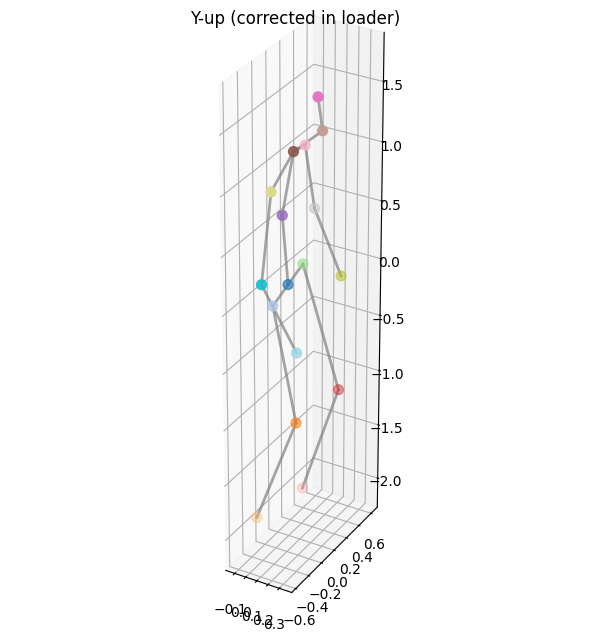

In [11]:
import matplotlib.pyplot as plt

FRAME = 500
frame_xyz = raw_processed[FRAME, :, 0:3].copy()
# no manual Y flip here — already corrected in the loader

H36M_SKELETON_EDGES = [
    (10,9),(9,8),(8,7),(7,0),(0,1),(1,2),(2,3),
    (0,4),(4,5),(5,6),
    (8,11),(11,12),(12,13),
    (8,14),(14,15),(15,16),
]

fig, ax = plt.subplots(figsize=(6, 8), subplot_kw={'projection': '3d'})
other_axes = [0, 2]
up_axis = 1

x = frame_xyz[:, other_axes[0]]
y = frame_xyz[:, other_axes[1]]
z = frame_xyz[:, up_axis]

ax.scatter(x, y, z, c=range(len(x)), cmap='tab20', s=50)
for j1, j2 in H36M_SKELETON_EDGES:
    ax.plot([frame_xyz[j1, other_axes[0]], frame_xyz[j2, other_axes[0]]],
            [frame_xyz[j1, other_axes[1]], frame_xyz[j2, other_axes[1]]],
            [frame_xyz[j1, up_axis], frame_xyz[j2, up_axis]],
            c='gray', alpha=0.7, linewidth=2)

ranges = frame_xyz.max(axis=0) - frame_xyz.min(axis=0)
ax.set_box_aspect([ranges[other_axes[0]], ranges[other_axes[1]], ranges[up_axis]])
ax.set_title("Y-up (corrected in loader)")
plt.tight_layout()
plt.show()


## 8. Hyperparameters (note: NO global FPS constant — use `clip_fps_kept` per clip)

In [12]:
MAX_ITER = 30
EPOCHS = 2000
VW_EPOCHS = 1000
BATCH_SIZE = 64
LR = 1e-3
WINDOW_SIZE = 30
LATENT_DIM = 64

MIN_SEGMENT_FRAMES = 20
MAX_SEGMENT_FRAMES = 300
MIN_WINDOWS = 150
MIN_PARTICIPANTS_PER_CLUSTER = 3

PERCENTILE_RANGE = (20, 80)
QUANTILE_RANGE   = (0.10, 0.30)

def clip_fps_for_frame(frame_idx):
    """Per-clip fps lookup — replaces the old single global FPS constant."""
    for clip_i, (start, end) in enumerate(clip_frame_ranges):
        if start <= frame_idx < end:
            return clip_fps_kept[clip_i]
    return 30  # fallback


## 9. Model + helper functions

In [13]:
class HierarchicalRAE(nn.Module):
    def __init__(self, joint_dim, joint_embed=32, pose_embed=128,
                 hidden_dim=256, latent_dim=LATENT_DIM, num_joints=N_JOINTS):
        super().__init__()
        self.num_joints = num_joints
        self.joint_encoder = nn.Sequential(
            nn.Linear(joint_dim, joint_embed), nn.Tanh(), nn.Linear(joint_embed, joint_embed))
        self.pose_encoder = nn.Sequential(
            nn.Linear(num_joints * joint_embed, pose_embed), nn.Tanh())
        self.encoder_rnn = nn.LSTM(pose_embed, hidden_dim, batch_first=True)
        self.fc_latent = nn.Linear(hidden_dim, latent_dim)
        self.fc_decode_h = nn.Linear(latent_dim, hidden_dim)
        self.fc_decode_c = nn.Linear(latent_dim, hidden_dim)
        self.decoder_rnn = nn.LSTM(latent_dim, hidden_dim, batch_first=True)
        self.decoder_proj = nn.Linear(hidden_dim, pose_embed)
        self.pose_decoder = nn.Sequential(
            nn.Linear(pose_embed, num_joints * joint_embed), nn.Tanh())
        self.joint_decoder = nn.Linear(joint_embed, joint_dim)
        self._init_weights()

    def _init_weights(self):
        nn.init.xavier_uniform_(self.fc_decode_h.weight, gain=2.0)
        nn.init.xavier_uniform_(self.fc_decode_c.weight, gain=2.0)
        nn.init.constant_(self.fc_decode_h.bias, 0.0)
        nn.init.constant_(self.fc_decode_c.bias, 0.0)
        nn.init.xavier_uniform_(self.fc_latent.weight, gain=2.0)
        nn.init.constant_(self.fc_latent.bias, 0.0)
        for name, param in self.decoder_rnn.named_parameters():
            if 'weight_ih' in name: nn.init.xavier_uniform_(param, gain=2.0)
            elif 'weight_hh' in name: nn.init.orthogonal_(param, gain=2.0)
            elif 'bias' in name: nn.init.zeros_(param)
        for name, param in self.encoder_rnn.named_parameters():
            if 'weight_ih' in name: nn.init.xavier_uniform_(param)
            elif 'weight_hh' in name: nn.init.orthogonal_(param)
            elif 'bias' in name: nn.init.zeros_(param)
        for module in [self.joint_encoder, self.pose_encoder, self.pose_decoder,
                       self.joint_decoder, self.decoder_proj]:
            if isinstance(module, nn.Sequential):
                for layer in module:
                    if isinstance(layer, nn.Linear):
                        nn.init.xavier_uniform_(layer.weight); nn.init.zeros_(layer.bias)
            elif isinstance(module, nn.Linear):
                nn.init.xavier_uniform_(module.weight); nn.init.zeros_(module.bias)

    def encode(self, x, lengths=None):
        B, T, J, C = x.shape
        x_flat = x.view(B * T * J, C)
        x_flat = self.joint_encoder(x_flat)
        x_enc  = x_flat.view(B, T, J, -1).view(B, T, -1)
        x_enc  = self.pose_encoder(x_enc)
        if lengths is not None:
            packed = pack_padded_sequence(x_enc, lengths.cpu(), batch_first=True, enforce_sorted=False)
            _, (h, _) = self.encoder_rnn(packed)
        else:
            _, (h, _) = self.encoder_rnn(x_enc)
        return self.fc_latent(h[-1])

    def decode(self, z, T):
        h = self.fc_decode_h(z).unsqueeze(0)
        c = self.fc_decode_c(z).unsqueeze(0)
        inp = z.unsqueeze(1).repeat(1, T, 1)
        dec, _ = self.decoder_rnn(inp, (h, c))
        return self.decoder_proj(dec)

    def forward(self, x, lengths=None):
        B, T, J, C = x.shape
        z = self.encode(x, lengths)
        dec = self.decode(z, T)
        dec = self.pose_decoder(dec).view(B, T, J, -1).view(B * T * J, -1)
        dec = self.joint_decoder(dec).view(B, T, J, C)
        return dec, z


def collate_variable_length(batch):
    lengths = [x.shape[0] for x in batch]
    B, T_max = len(batch), max(lengths)
    J, C = batch[0].shape[1], batch[0].shape[2]
    padded = torch.zeros(B, T_max, J, C)
    for i, x in enumerate(batch):
        padded[i, :lengths[i]] = x
    return padded, torch.tensor(lengths, dtype=torch.long)


def extract_nonoverlapping_windows(raw_sequence, window_size):
    n_frames = len(raw_sequence)
    windows = np.array([raw_sequence[s:s+window_size] for s in range(0, n_frames - window_size, window_size)])
    print(f"Extracted {len(windows)} non-overlapping windows")
    return windows


def train_on_fixed_windows(raw_sequence, window_size=WINDOW_SIZE, epochs=EPOCHS,
                            batch_size=BATCH_SIZE, lr=LR, device=device, patience=30):
    windows = extract_nonoverlapping_windows(raw_sequence, window_size)
    X_tensor = torch.tensor(windows, dtype=torch.float32)
    n_joints, joint_dim = raw_sequence.shape[1], raw_sequence.shape[2]
    from torch.utils.data import TensorDataset
    loader = DataLoader(TensorDataset(X_tensor), batch_size=batch_size, shuffle=True)

    model = HierarchicalRAE(latent_dim=LATENT_DIM, joint_dim=joint_dim, num_joints=n_joints).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)
    loss_fn = nn.MSELoss()
    best_loss, patience_ctr, best_weights, lossgraph = float('inf'), 0, None, []

    for epoch in range(epochs):
        total_loss = 0
        for (batch,) in loader:
            batch = batch.to(device)
            recon, _ = model(batch)
            loss = loss_fn(recon, batch)
            optimizer.zero_grad(); loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            total_loss += loss.item()
        avg = total_loss / len(loader)
        lossgraph.append(avg); scheduler.step(avg)
        if avg < best_loss - 1e-4:
            best_loss, patience_ctr = avg, 0
            best_weights = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            patience_ctr += 1
        if patience_ctr >= patience:
            print(f"Early stopping at epoch {epoch+1} — best loss: {best_loss:.6f}")
            model.load_state_dict(best_weights); break
        if (epoch + 1) % 5 == 0:
            print(f"Epoch {epoch+1}/{epochs} — Loss: {avg:.6f}")
    return model, lossgraph


def train_on_variable_windows(raw_sequence, windows, epochs=VW_EPOCHS, batch_size=BATCH_SIZE,
                               lr=LR, device=device, patience=30):
    n_joints, joint_dim = raw_sequence.shape[1], raw_sequence.shape[2]
    tensor_list = [torch.tensor(w, dtype=torch.float32) for w in windows]
    loader = DataLoader(tensor_list, batch_size=batch_size, shuffle=True, collate_fn=collate_variable_length)
    model = HierarchicalRAE(latent_dim=LATENT_DIM, joint_dim=joint_dim, num_joints=n_joints).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)
    loss_fn = nn.MSELoss()
    best_loss, patience_ctr, best_weights, lossgraph = float('inf'), 0, None, []

    for epoch in range(epochs):
        total_loss = 0
        for padded, lengths in loader:
            padded = padded.to(device)
            recon, _ = model(padded, lengths=lengths)
            loss = torch.tensor(0.0, device=device)
            for i, l in enumerate(lengths):
                loss = loss + loss_fn(recon[i, :l], padded[i, :l])
            loss = loss / len(lengths)
            optimizer.zero_grad(); loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            total_loss += loss.item()
        avg = total_loss / len(loader)
        lossgraph.append(avg); scheduler.step(avg)
        if avg < best_loss - 1e-4:
            best_loss, patience_ctr = avg, 0
            best_weights = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            patience_ctr += 1
        if patience_ctr >= patience:
            print(f"Early stopping at epoch {epoch+1} — best loss: {best_loss:.6f}")
            model.load_state_dict(best_weights); break
        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1}/{epochs} — Loss: {avg:.6f}")
    return model, lossgraph


def compute_frame_loss(model, raw_sequence, window_size, stride=5, device=device):
    model.eval()
    losses, positions = [], []
    raw_tensor = torch.tensor(raw_sequence, dtype=torch.float32, device=device)
    loss_fn = nn.MSELoss()
    with torch.no_grad():
        for start in range(0, len(raw_sequence) - window_size, stride):
            window = raw_tensor[start:start + window_size].unsqueeze(0)
            recon, _ = model(window)
            losses.append(loss_fn(recon, window).item())
            positions.append(start + window_size // 2)
    positions, losses = np.array(positions), np.array(losses)
    print(f"Computed loss at {len(losses)} positions")
    return positions, losses


def find_transitions(positions, losses, percentile=70, smoothing=5, min_distance=3, fps=30):
    if len(losses) < smoothing:
        smoothing = max(3, len(losses) // 2)
        if smoothing % 2 == 0: smoothing += 1
    smoothed = savgol_filter(losses, window_length=smoothing, polyorder=2)
    threshold = np.percentile(smoothed, percentile)
    peaks, _ = find_peaks(smoothed, height=threshold, distance=min_distance)
    transition_frames = positions[peaks]
    if len(transition_frames) > 1:
        mean_bout = np.mean(np.diff(transition_frames)) / fps
        print(f"Found {len(transition_frames)} transitions, mean bout duration: {mean_bout:.2f}s (using fps={fps})")
    return transition_frames, smoothed


def create_windows_from_transitions(raw_sequence, transition_frames,
                                     min_segment_frames=MIN_SEGMENT_FRAMES, max_segment_frames=MAX_SEGMENT_FRAMES):
    n_frames = len(raw_sequence)
    boundaries = np.unique(np.concatenate([[0], transition_frames, [n_frames]])).astype(int)
    all_windows, window_labels, window_starts = [], [], []
    for seg_idx in range(len(boundaries) - 1):
        seg_start, seg_end = boundaries[seg_idx], boundaries[seg_idx + 1]
        seg_len = seg_end - seg_start
        if seg_len < min_segment_frames:
            continue
        segment = raw_sequence[seg_start:seg_end]
        for start in range(0, seg_len, max_segment_frames):
            chunk = segment[start:start + max_segment_frames]
            if len(chunk) < min_segment_frames:
                continue
            all_windows.append(chunk)
            window_labels.append(seg_idx)
            window_starts.append(seg_start + start)
    lengths = [len(w) for w in all_windows]
    print(f"Created {len(all_windows)} variable-length windows from {len(boundaries) - 1} segments")
    if lengths:
        print(f"Window lengths — min: {min(lengths)}, max: {max(lengths)}, mean: {np.mean(lengths):.1f}")
    return all_windows, np.array(window_labels), np.array(window_starts)


def create_windows_from_transitions_clip_safe(raw_sequence, transition_frames, clip_frame_ranges,
                                                min_segment_frames=MIN_SEGMENT_FRAMES,
                                                max_segment_frames=MAX_SEGMENT_FRAMES):
    """Forces a hard cut at every clip's start frame — prevents windows spanning
    multiple walks/participants, the same bug found and fixed for REMAP."""
    clip_starts = np.array([start for start, end in clip_frame_ranges])
    all_boundaries = np.unique(np.concatenate([transition_frames, clip_starts]))
    return create_windows_from_transitions(raw_sequence, all_boundaries,
                                            min_segment_frames, max_segment_frames)


def frame_to_clip(frame_idx):
    for clip_i, (start, end) in enumerate(clip_frame_ranges):
        if start <= frame_idx < end:
            return clip_i
    return -1


def encode_and_cluster(model, windows, batch_size=BATCH_SIZE, device=device, quantile=0.1,
                        umap_neighbors=30, umap_min_dist=0.1):
    model.eval()
    all_latents = []
    tensor_list = [torch.tensor(w, dtype=torch.float32) for w in windows]
    loader = DataLoader(tensor_list, batch_size=batch_size, shuffle=False, collate_fn=collate_variable_length)
    with torch.no_grad():
        for padded, lengths in loader:
            padded = padded.to(device)
            _, z = model(padded, lengths=lengths)
            all_latents.append(z.cpu().numpy())
    all_latents = np.concatenate(all_latents, axis=0)
    print(f"Latents shape: {all_latents.shape}")

    reducer = UMAP(n_components=2, n_neighbors=umap_neighbors, min_dist=umap_min_dist,
                  metric='cosine', random_state=42)
    latents_2d = reducer.fit_transform(all_latents)
    print(f"UMAP done. Shape: {latents_2d.shape}")

    normed = normalize(latents_2d, norm='l2')
    bandwidth = estimate_bandwidth(normed, quantile=quantile)
    ms = MeanShift(bandwidth=bandwidth, bin_seeding=True)
    ms.fit(normed)
    cluster_labels = ms.labels_
    n_clusters = len(np.unique(cluster_labels))
    print(f"Found {n_clusters} clusters, sizes: {np.bincount(cluster_labels)}")

    if n_clusters > 1:
        dist_matrix = np.clip(1 - np.dot(normed, normed.T), 0, 2)
        sil = silhouette_score(dist_matrix, cluster_labels, metric='precomputed')
        print(f"Silhouette score: {sil:.4f}")

    return all_latents, latents_2d, cluster_labels, ms


## 10. Stage 1 training + reconstruction loss

Extracted 2805 non-overlapping windows
Epoch 5/2000 — Loss: 0.014414
Epoch 10/2000 — Loss: 0.014251
Epoch 15/2000 — Loss: 0.014221
Epoch 20/2000 — Loss: 0.014143
Epoch 25/2000 — Loss: 0.014099
Epoch 30/2000 — Loss: 0.014109
Epoch 35/2000 — Loss: 0.014090
Epoch 40/2000 — Loss: 0.014088
Epoch 45/2000 — Loss: 0.014083
Epoch 50/2000 — Loss: 0.014060
Epoch 55/2000 — Loss: 0.014005
Epoch 60/2000 — Loss: 0.013162
Epoch 65/2000 — Loss: 0.012474
Epoch 70/2000 — Loss: 0.011562
Epoch 75/2000 — Loss: 0.010501
Epoch 80/2000 — Loss: 0.009942
Epoch 85/2000 — Loss: 0.009527
Epoch 90/2000 — Loss: 0.009300
Epoch 95/2000 — Loss: 0.009530
Epoch 100/2000 — Loss: 0.009807
Epoch 105/2000 — Loss: 0.009098
Epoch 110/2000 — Loss: 0.008651
Epoch 115/2000 — Loss: 0.008916
Epoch 120/2000 — Loss: 0.009291
Epoch 125/2000 — Loss: 0.009261
Epoch 130/2000 — Loss: 0.008509
Epoch 135/2000 — Loss: 0.008466
Epoch 140/2000 — Loss: 0.008471
Epoch 145/2000 — Loss: 0.008658
Epoch 150/2000 — Loss: 0.008428
Epoch 155/2000 — Loss

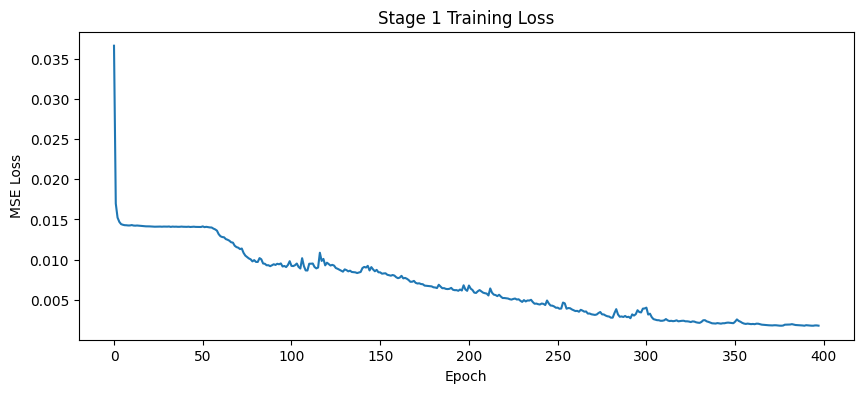

Computed loss at 42068 positions


In [14]:
model_stage1, lossgraph_stage1 = train_on_fixed_windows(
    raw_processed, window_size=WINDOW_SIZE, epochs=EPOCHS, device=device
)
torch.save(model_stage1.state_dict(), 'carepd_model_stage1.pth')

plt.figure(figsize=(10, 4))
plt.plot(lossgraph_stage1)
plt.title('Stage 1 Training Loss'); plt.xlabel('Epoch'); plt.ylabel('MSE Loss')
plt.show()

positions, losses = compute_frame_loss(model_stage1, raw_processed, window_size=WINDOW_SIZE, stride=2, device=device)


## 11a. Bayesian search — UPDRS-gait severity (epsilon², ordinal)

In [16]:
search_space = [
    Real(*PERCENTILE_RANGE, name='percentile'),
    Real(*QUANTILE_RANGE, name='quantile'),
]
search_log = []
best_results_fog = None
best_score = -1
iteration = 0

@use_named_args(search_space)
def objective_fog(percentile, quantile):
    global iteration, best_score, best_results_fog
    iteration += 1
    print(f"\n{'='*60}\nITER {iteration}/{MAX_ITER} | percentile={percentile:.2f}, quantile={quantile:.4f}\n{'='*60}")

    median_fps = int(np.median(clip_fps_kept))
    transition_frames, smoothed = find_transitions(positions, losses, percentile=percentile, fps=median_fps)
    windows, _wl, window_starts = create_windows_from_transitions_clip_safe(
        raw_processed, transition_frames, clip_frame_ranges
    )
    if len(windows) < MIN_WINDOWS:
        print(f"  only {len(windows)} windows (<{MIN_WINDOWS}) — skipping")
        return 0.0

    window_clip_id     = np.array([frame_to_clip(window_starts[w]) for w in range(len(windows))])
    window_fog          = fog_labels_kept[window_clip_id]
    window_walk_base    = clip_walk_base_kept[window_clip_id]
    window_participant  = clip_participant_kept[window_clip_id]

    model_file = f"carepd_model_fog_{iteration}.pth"
    if Path(model_file).is_file():
        n_joints, joint_dim = raw_processed.shape[1], raw_processed.shape[2]
        checkpoint = torch.load(model_file, weights_only=True)
        saved_latent_dim = checkpoint['fc_latent.weight'].shape[0]
        model = HierarchicalRAE(latent_dim=saved_latent_dim, joint_dim=joint_dim, num_joints=n_joints).to(device)
        model.load_state_dict(checkpoint)
    else:
        model, _ = train_on_variable_windows(raw_processed, windows, epochs=VW_EPOCHS, lr=LR, device=device)
        torch.save(model.state_dict(), model_file)

    latents, latents_2d, cluster_labels, ms_model = encode_and_cluster(
        model, windows, quantile=quantile, umap_neighbors=15, umap_min_dist=0.1, device=device
    )
    n_clusters = len(np.unique(cluster_labels))

    if n_clusters < 2 or n_clusters >= len(latents_2d):
        print(f"  → {n_clusters} clusters — invalid, skipping")
        score = 0.0
    else:
        df = pd.DataFrame({'cluster': cluster_labels, 'fog': window_fog, 'participant': window_participant})
        df = df[~pd.isna(df['fog'])]

        diversity = df.groupby('cluster')['participant'].nunique()
        valid_clusters = diversity[diversity >= MIN_PARTICIPANTS_PER_CLUSTER].index
        df_valid = df[df['cluster'].isin(valid_clusters)]

        n_excluded = len(df) - len(df_valid)
        if n_excluded:
            print(f"  excluding {n_excluded} windows in clusters with "
                  f"<{MIN_PARTICIPANTS_PER_CLUSTER} distinct participants")

        if len(df_valid) < 20 or df_valid['cluster'].nunique() < 2:
            print("  not enough valid (multi-participant) clusters — skipping")
            score = 0.0
        else:
            score = normalized_mutual_info_score(df_valid['fog'].values, df_valid['cluster'].values)
            print(f"  → {n_clusters} clusters ({len(valid_clusters)} valid), NMI(fog)={score:.4f}")

    search_log.append({'iteration': iteration, 'percentile': round(percentile, 2), 'quantile': round(quantile, 4),
                        'n_clusters': n_clusters, 'nmi_fog': round(float(score), 4)})

    if score > best_score:
        best_score = score
        best_results_fog = {
            'model': model, 'model_stage1': model_stage1, 'latents': latents, 'latents_2d': latents_2d,
            'cluster_labels': cluster_labels, 'windows': windows, 'window_starts': window_starts,
            '_percentile': percentile, '_quantile': quantile,
        }
        print(f"  ** NEW BEST (NMI={score:.4f}) **")

    del model, latents, latents_2d, cluster_labels, ms_model
    import gc; gc.collect()
    if torch.cuda.is_available(): torch.cuda.empty_cache()
    return -score

bayes_result = gp_minimize(func=objective_fog, dimensions=search_space,
                            n_calls=MAX_ITER, n_initial_points=min(MAX_ITER, 5), random_state=42)
print(f"\nBest FOG NMI = {best_score:.4f}")
results_fog = best_results_fog


ITER 1/30 | percentile=67.79, quantile=0.1367
Found 3613 transitions, mean bout duration: 0.78s (using fps=30)
Created 926 variable-length windows from 7351 segments
Window lengths — min: 20, max: 89, mean: 27.9
Epoch 10/1000 — Loss: 0.007356
Epoch 20/1000 — Loss: 0.006798
Epoch 30/1000 — Loss: 0.005948
Epoch 40/1000 — Loss: 0.004734
Epoch 50/1000 — Loss: 0.003910
Epoch 60/1000 — Loss: 0.002825
Epoch 70/1000 — Loss: 0.002531
Epoch 80/1000 — Loss: 0.001915
Epoch 90/1000 — Loss: 0.001555
Epoch 100/1000 — Loss: 0.001464
Epoch 110/1000 — Loss: 0.001384
Epoch 120/1000 — Loss: 0.001256
Epoch 130/1000 — Loss: 0.001202
Epoch 140/1000 — Loss: 0.000772
Epoch 150/1000 — Loss: 0.000858
Epoch 160/1000 — Loss: 0.000761
Epoch 170/1000 — Loss: 0.000668
Epoch 180/1000 — Loss: 0.000649
Epoch 190/1000 — Loss: 0.000647
Early stopping at epoch 199 — best loss: 0.000672
Latents shape: (926, 64)


/opt/miniconda3/envs/carepd/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP done. Shape: (926, 2)
Found 8 clusters, sizes: [360 210 171  66  41  40  26  12]
Silhouette score: 0.7847
  excluding 79 windows in clusters with <3 distinct participants
  → 8 clusters (5 valid), NMI(fog)=0.0786
  ** NEW BEST (NMI=0.0786) **

ITER 2/30 | percentile=66.78, quantile=0.2194
Found 3696 transitions, mean bout duration: 0.76s (using fps=30)
Created 902 variable-length windows from 7430 segments
Window lengths — min: 20, max: 89, mean: 28.0
Epoch 10/1000 — Loss: 0.007384
Epoch 20/1000 — Loss: 0.006768
Epoch 30/1000 — Loss: 0.006696
Epoch 40/1000 — Loss: 0.005537
Epoch 50/1000 — Loss: 0.004940
Epoch 60/1000 — Loss: 0.003097
Epoch 70/1000 — Loss: 0.002841
Epoch 80/1000 — Loss: 0.002488
Epoch 90/1000 — Loss: 0.002034
Epoch 100/1000 — Loss: 0.001698
Epoch 110/1000 — Loss: 0.001419
Epoch 120/1000 — Loss: 0.001307
Epoch 130/1000 — Loss: 0.001603
Epoch 140/1000 — Loss: 0.001076
Epoch 150/1000 — Loss: 0.001120
Epoch 160/1000 — Loss: 0.000944
Epoch 170/1000 — Loss: 0.000894
Epoc

/opt/miniconda3/envs/carepd/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP done. Shape: (902, 2)
Found 5 clusters, sizes: [419 311  81  69  22]
Silhouette score: 0.7488
  excluding 172 windows in clusters with <3 distinct participants
  → 5 clusters (2 valid), NMI(fog)=0.3122
  ** NEW BEST (NMI=0.3122) **

ITER 3/30 | percentile=46.75, quantile=0.1200
Found 5463 transitions, mean bout duration: 0.51s (using fps=30)
Created 541 variable-length windows from 9125 segments
Window lengths — min: 20, max: 86, mean: 28.2
Epoch 10/1000 — Loss: 0.007109
Epoch 20/1000 — Loss: 0.005801
Epoch 30/1000 — Loss: 0.005613
Epoch 40/1000 — Loss: 0.004997
Epoch 50/1000 — Loss: 0.004067
Epoch 60/1000 — Loss: 0.003848
Epoch 70/1000 — Loss: 0.003802
Epoch 80/1000 — Loss: 0.003098
Epoch 90/1000 — Loss: 0.002684
Epoch 100/1000 — Loss: 0.002410
Epoch 110/1000 — Loss: 0.002299
Epoch 120/1000 — Loss: 0.002171
Epoch 130/1000 — Loss: 0.001749
Epoch 140/1000 — Loss: 0.001740
Epoch 150/1000 — Loss: 0.001432
Epoch 160/1000 — Loss: 0.001374
Epoch 170/1000 — Loss: 0.001110
Epoch 180/1000 

/opt/miniconda3/envs/carepd/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP done. Shape: (541, 2)
Found 9 clusters, sizes: [174 115 112  35  26  35  24  15   5]
Silhouette score: 0.7809
  excluding 140 windows in clusters with <3 distinct participants
  → 9 clusters (3 valid), NMI(fog)=0.2620

ITER 4/30 | percentile=47.55, quantile=0.1667
Found 5384 transitions, mean bout duration: 0.52s (using fps=30)
Created 549 variable-length windows from 9046 segments
Window lengths — min: 20, max: 86, mean: 28.2
Epoch 10/1000 — Loss: 0.007421
Epoch 20/1000 — Loss: 0.005870
Epoch 30/1000 — Loss: 0.005752
Epoch 40/1000 — Loss: 0.005534
Epoch 50/1000 — Loss: 0.004219
Epoch 60/1000 — Loss: 0.003885
Epoch 70/1000 — Loss: 0.003602
Epoch 80/1000 — Loss: 0.003303
Epoch 90/1000 — Loss: 0.003377
Epoch 100/1000 — Loss: 0.002964
Epoch 110/1000 — Loss: 0.002982
Epoch 120/1000 — Loss: 0.002576
Epoch 130/1000 — Loss: 0.002416
Epoch 140/1000 — Loss: 0.002170
Epoch 150/1000 — Loss: 0.002085
Epoch 160/1000 — Loss: 0.001612
Epoch 170/1000 — Loss: 0.001529
Epoch 180/1000 — Loss: 0.0015

KeyboardInterrupt: 

## 11b. Bayesian search — medication state (NMI, categorical, PD-only)

In [ ]:
search_space = [
    Real(*PERCENTILE_RANGE, name='percentile'),
    Real(*QUANTILE_RANGE, name='quantile'),
]
search_log_med = []
best_results_medication = None
best_score_med = -1
iteration = 0

@use_named_args(search_space)
def objective_medication(percentile, quantile):
    global iteration, best_score_med, best_results_medication
    iteration += 1
    print(f"\n{'='*60}\nITER {iteration}/{MAX_ITER} | percentile={percentile:.2f}, quantile={quantile:.4f}\n{'='*60}")

    median_fps = int(np.median(clip_fps_kept))
    transition_frames, smoothed = find_transitions(positions, losses, percentile=percentile, fps=median_fps)
    windows, _wl, window_starts = create_windows_from_transitions_clip_safe(
        raw_processed, transition_frames, clip_frame_ranges
    )
    if len(windows) < MIN_WINDOWS:
        print(f"  only {len(windows)} windows (<{MIN_WINDOWS}) — skipping")
        return 0.0

    window_clip_id = np.array([frame_to_clip(window_starts[w]) for w in range(len(windows))])
    window_med = medication_labels_kept[window_clip_id]
    window_participant = clip_participant_kept[window_clip_id]

    valid_mask = window_med != None
    print(f"  windows with resolved medication state: {valid_mask.sum()} / {len(windows)}")

    model_file = f"carepd_model_medication_{iteration}.pth"
    if Path(model_file).is_file():
        n_joints, joint_dim = raw_processed.shape[1], raw_processed.shape[2]
        checkpoint = torch.load(model_file, weights_only=True)
        saved_latent_dim = checkpoint['fc_latent.weight'].shape[0]
        model = HierarchicalRAE(latent_dim=saved_latent_dim, joint_dim=joint_dim, num_joints=n_joints).to(device)
        model.load_state_dict(checkpoint)
    else:
        model, _ = train_on_variable_windows(raw_processed, windows, epochs=VW_EPOCHS, lr=LR, device=device)
        torch.save(model.state_dict(), model_file)

    latents, latents_2d, cluster_labels, ms_model = encode_and_cluster(
        model, windows, quantile=quantile, umap_neighbors=15, umap_min_dist=0.1, device=device
    )
    n_clusters = len(np.unique(cluster_labels))

    if n_clusters < 2 or n_clusters >= len(latents_2d) or valid_mask.sum() < 20:
        print(f"  → {n_clusters} clusters — invalid, skipping")
        nmi = 0.0
    else:
        df = pd.DataFrame({'cluster': cluster_labels[valid_mask], 'medication': window_med[valid_mask],
                            'participant': window_participant[valid_mask]})
        diversity = df.groupby('cluster')['participant'].nunique()
        valid_clusters = diversity[diversity >= MIN_PARTICIPANTS_PER_CLUSTER].index
        df_valid = df[df['cluster'].isin(valid_clusters)]

        if len(df_valid) < 20 or df_valid['cluster'].nunique() < 2:
            print("  not enough valid (multi-participant) clusters — skipping")
            nmi = 0.0
        else:
            nmi = normalized_mutual_info_score(df_valid['medication'], df_valid['cluster'])
            print(f"  → {n_clusters} clusters ({len(valid_clusters)} valid), NMI={nmi:.4f}")

    search_log_med.append({'iteration': iteration, 'percentile': round(percentile, 2), 'quantile': round(quantile, 4),
                            'n_clusters': n_clusters, 'nmi': round(float(nmi), 4)})

    if nmi > best_score_med:
        best_score_med = nmi
        best_results_medication = {
            'model': model, 'model_stage1': model_stage1, 'latents': latents, 'latents_2d': latents_2d,
            'cluster_labels': cluster_labels, 'windows': windows, 'window_starts': window_starts,
            '_percentile': percentile, '_quantile': quantile,
        }
        print(f"  ** NEW BEST (NMI={nmi:.4f}) **")

    del model, latents, latents_2d, cluster_labels, ms_model
    import gc; gc.collect()
    if torch.cuda.is_available(): torch.cuda.empty_cache()
    return -nmi

bayes_result_med = gp_minimize(func=objective_medication, dimensions=search_space,
                                n_calls=MAX_ITER, n_initial_points=min(MAX_ITER, 5), random_state=42)
print(f"\nBest medication NMI = {best_score_med:.4f}")
results_medication = best_results_medication


## 12. Validate: severity clusters (boxplot + subject diversity, base-walk-aware)

In [ ]:
cluster_labels = results_severity['cluster_labels']
windows = results_severity['windows']
starts = results_severity['window_starts']

window_clip_id = np.array([frame_to_clip(starts[w]) for w in range(len(windows))])
window_severity = severity_labels_kept[window_clip_id]
window_participant = clip_participant_kept[window_clip_id]
window_walk_base = clip_walk_base_kept[window_clip_id]

val_mask = ~np.isnan(window_severity)
summary_df = pd.DataFrame({'cluster': cluster_labels[val_mask], 'severity': window_severity[val_mask],
                            'participant': window_participant[val_mask], 'walk_base': window_walk_base[val_mask]})

print("Per-cluster UPDRS_GAIT severity:")
print(summary_df.groupby('cluster')['severity'].agg(['count', 'mean', 'median', 'std']).round(3))
print("\nDistinct PARTICIPANTS per cluster:")
print(summary_df.groupby('cluster')['participant'].nunique())
print("\nDistinct BASE WALKS per cluster (collapsing BMCLab down-variants):")
print(summary_df.groupby('cluster')['walk_base'].nunique())

fig, ax = plt.subplots(figsize=(1.5 * summary_df['cluster'].nunique() + 3, 5))
sns.boxplot(data=summary_df, x='cluster', y='severity', hue='cluster', palette='viridis', legend=False, ax=ax)
ax.set_title('UPDRS_GAIT severity by cluster')
plt.tight_layout()
plt.show()


## 13. Validate: medication clusters (crosstab + subject diversity, base-walk-aware)

In [ ]:
cluster_labels_med = results_medication['cluster_labels']
windows_med = results_medication['windows']
starts_med = results_medication['window_starts']

window_clip_id_med = np.array([frame_to_clip(starts_med[w]) for w in range(len(windows_med))])
window_med_state = medication_labels_kept[window_clip_id_med]
window_participant_med = clip_participant_kept[window_clip_id_med]
window_walk_base_med = clip_walk_base_kept[window_clip_id_med]

val_mask_med = window_med_state != None
med_df = pd.DataFrame({'cluster': cluster_labels_med[val_mask_med], 'medication': window_med_state[val_mask_med],
                        'participant': window_participant_med[val_mask_med], 'walk_base': window_walk_base_med[val_mask_med]})

print(f"Windows with medication state: {len(med_df)} / {len(windows_med)}")
ct = pd.crosstab(med_df['cluster'], med_df['medication'])
print("\nCluster vs medication:")
print(ct)
chi2, p_val, dof, exp = chi2_contingency(ct)
print(f"Chi-square p={p_val:.4g}")

print("\nDistinct PARTICIPANTS per cluster:")
print(med_df.groupby('cluster')['participant'].nunique())
print("\nDistinct BASE WALKS per cluster:")
print(med_df.groupby('cluster')['walk_base'].nunique())

ct_prop = ct.div(ct.sum(axis=1), axis=0)
fig, ax = plt.subplots(figsize=(1.5 * len(ct) + 3, 5))
ct_prop.plot(kind='bar', stacked=True, ax=ax)
ax.set_title(f'Medication proportion per cluster (p={p_val:.3f})')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 14. Kinematic feature characterization — severity clusters

Same diagnostic used on LA and REMAP: extract per-window kinematic features directly (no clustering involved in the feature computation itself), then test which features actually differ across the clusters the severity search found. This is what caught the LA heading-alignment artifact earlier in this project — worth running before trusting that any cluster split found by Section 11a reflects real movement differences rather than an incidental axis like heading/orientation.

In [ ]:
def window_kinematic_features_3d(window_data):
    """
    window_data: (T, 17, 10) slice of raw_processed for one window.
    Channels: 0-2 position | 3-5 velocity | 6 ang_vel | 7 speed | 8-9 sin/cos heading
    """
    pos     = window_data[:, :, 0:3]
    vel     = window_data[:, :, 3:6]
    ang_vel = window_data[:, :, 6]
    speed   = window_data[:, :, 7]

    mean_speed = speed.mean()
    peak_speed = speed.max()

    accel = np.diff(vel, axis=0)
    accel_mag = np.linalg.norm(accel, axis=-1)
    mean_accel = accel_mag.mean() if accel_mag.size > 0 else np.nan

    jerk = np.diff(accel, axis=0)
    jerk_mag = np.linalg.norm(jerk, axis=-1)
    mean_jerk = jerk_mag.mean() if jerk_mag.size > 0 else np.nan

    dist_from_hip = np.linalg.norm(pos, axis=-1)  # per-joint distance from hip center, per frame
    amplitude = (dist_from_hip.max(axis=0) - dist_from_hip.min(axis=0)).mean()

    mean_ang_vel = np.abs(ang_vel).mean()

    return {
        'mean_speed': mean_speed, 'peak_speed': peak_speed,
        'mean_accel': mean_accel, 'mean_jerk': mean_jerk,
        'amplitude': amplitude, 'mean_ang_vel': mean_ang_vel,
        'duration_frames': window_data.shape[0],
    }


from scipy.stats import mannwhitneyu

windows_sev = results_severity['windows']
cluster_labels_sev = results_severity['cluster_labels']

feature_rows_sev = []
for w in range(len(windows_sev)):
    feats = window_kinematic_features_3d(windows_sev[w])
    feats['cluster'] = cluster_labels_sev[w]
    feature_rows_sev.append(feats)

feature_df_sev = pd.DataFrame(feature_rows_sev)
feature_cols = ['mean_speed', 'peak_speed', 'mean_accel', 'mean_jerk', 'amplitude', 'mean_ang_vel', 'duration_frames']

print("Per-cluster kinematic summary (severity clustering):")
print(feature_df_sev.groupby('cluster')[feature_cols].agg(['mean', 'median', 'std']).round(4))

clusters_present_sev = sorted(feature_df_sev['cluster'].unique())
print(f"\n{len(clusters_present_sev)} clusters present: {clusters_present_sev}")

if len(clusters_present_sev) == 2:
    c0, c1 = clusters_present_sev
    print(f"\nMann-Whitney U tests (cluster {c0} vs cluster {c1}):")
    results_table = []
    for col in feature_cols:
        g0 = feature_df_sev[feature_df_sev.cluster == c0][col].dropna()
        g1 = feature_df_sev[feature_df_sev.cluster == c1][col].dropna()
        u, p = mannwhitneyu(g0, g1, alternative='two-sided')
        results_table.append({'feature': col, f'cluster{c0}_median': round(g0.median(), 4),
                               f'cluster{c1}_median': round(g1.median(), 4), 'p_value': round(p, 4)})
    print(pd.DataFrame(results_table).sort_values('p_value').to_string(index=False))
else:
    print(f"\n>2 clusters present — running Kruskal-Wallis per feature instead of pairwise Mann-Whitney:")
    for col in feature_cols:
        groups = [g[col].dropna().values for _, g in feature_df_sev.groupby('cluster')]
        groups = [g for g in groups if len(g) > 0]
        if len(groups) >= 2:
            h_stat, p = kruskal(*groups)
            print(f"  {col}: H={h_stat:.3f}, p={p:.4g}")

fig, axes = plt.subplots(1, len(feature_cols), figsize=(3.2 * len(feature_cols), 4))
for ax, col in zip(axes, feature_cols):
    sns.boxplot(data=feature_df_sev, x='cluster', y=col, hue='cluster', palette='viridis', legend=False, ax=ax)
    ax.set_title(col, fontsize=9)
plt.tight_layout()
plt.show()


## 15. Kinematic feature characterization — medication clusters

Same test, applied to the medication-state clustering from Section 11b (BMCLab-only, per the earlier per-cohort coverage check).

In [ ]:
windows_med = results_medication['windows']
cluster_labels_med_k = results_medication['cluster_labels']

feature_rows_med = []
for w in range(len(windows_med)):
    feats = window_kinematic_features_3d(windows_med[w])
    feats['cluster'] = cluster_labels_med_k[w]
    feature_rows_med.append(feats)

feature_df_med = pd.DataFrame(feature_rows_med)

print("Per-cluster kinematic summary (medication clustering):")
print(feature_df_med.groupby('cluster')[feature_cols].agg(['mean', 'median', 'std']).round(4))

clusters_present_med = sorted(feature_df_med['cluster'].unique())
print(f"\n{len(clusters_present_med)} clusters present: {clusters_present_med}")

if len(clusters_present_med) == 2:
    c0, c1 = clusters_present_med
    print(f"\nMann-Whitney U tests (cluster {c0} vs cluster {c1}):")
    results_table = []
    for col in feature_cols:
        g0 = feature_df_med[feature_df_med.cluster == c0][col].dropna()
        g1 = feature_df_med[feature_df_med.cluster == c1][col].dropna()
        u, p = mannwhitneyu(g0, g1, alternative='two-sided')
        results_table.append({'feature': col, f'cluster{c0}_median': round(g0.median(), 4),
                               f'cluster{c1}_median': round(g1.median(), 4), 'p_value': round(p, 4)})
    print(pd.DataFrame(results_table).sort_values('p_value').to_string(index=False))
else:
    print(f"\n>2 clusters present — running Kruskal-Wallis per feature instead of pairwise Mann-Whitney:")
    for col in feature_cols:
        groups = [g[col].dropna().values for _, g in feature_df_med.groupby('cluster')]
        groups = [g for g in groups if len(g) > 0]
        if len(groups) >= 2:
            h_stat, p = kruskal(*groups)
            print(f"  {col}: H={h_stat:.3f}, p={p:.4g}")

fig, axes = plt.subplots(1, len(feature_cols), figsize=(3.2 * len(feature_cols), 4))
for ax, col in zip(axes, feature_cols):
    sns.boxplot(data=feature_df_med, x='cluster', y=col, hue='cluster', palette='viridis', legend=False, ax=ax)
    ax.set_title(col, fontsize=9)
plt.tight_layout()
plt.show()
